# Melanoma Phosphorylation Analysis — ESM2 Pipeline

Mirrors the LUAD EGFR-NAT ESM2 clean pipeline, adapted for melanoma:
- Data: `Filtered_data_Prostate_Palbocilib_Phospho.csv`
- Labels: **PTM-up (1)** vs **PTM-down (0)**
- Embedder: **ESM2 esm2_t33_650M_UR50D** (1280-dim), full-protein → 15-mer window slice
- Models: MaxPool MLP · AttnPool MLP · CenterOnly MLP · Hybrid (C+Attn)

**Outline**
1. Imports & Setup
2. Load & Clean Data / Assign Labels
3. ESM2 Full-Protein Embeddings (cached)
4. 15-mer Window Extraction
5. Classification Heads + Training
6. Publication-Grade Figures

In [1]:
# ── 1. Imports & Setup ───────────────────────────────────────────────────────
from pathlib import Path
import hashlib
import random
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix,
    precision_score, recall_score, f1_score,
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm

# ── Publication style (mirrors EGFR pipeline) ────────────────────────────────
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.dpi":        140,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.labelweight":  "bold",
    "axes.titleweight":  "bold",
    "axes.titlesize":    13,
    "axes.labelsize":    12,
    "xtick.labelsize":   11,
    "ytick.labelsize":   11,
    "legend.fontsize":   10,
    "savefig.bbox":      "tight",
    "savefig.dpi":       300,
})

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Paths ────────────────────────────────────────────────────────────────────
PDMAS_DIR    = Path("/home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response")
MELANOMA_DATA = PDMAS_DIR / "Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/Filtered_data_Melanoma_ARi_Phospho.csv"
RESULTS_DIR  = PDMAS_DIR / "Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/results_melanoma_phospho_esm2"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
EMBED_CACHE  = RESULTS_DIR / "esm2_full_protein_embeddings.npz"

import transformers
print(f"PyTorch device    : {device}")
print(f"Transformers ver  : {transformers.__version__}")
print(f"Melanoma data     : {MELANOMA_DATA.exists()} — {MELANOMA_DATA}")
print(f"Results dir       : {RESULTS_DIR}")
print(f"Embed cache       : {EMBED_CACHE.exists()} — {EMBED_CACHE}")

/home/saishyam/ankh_env/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch device    : cuda
Transformers ver  : 4.57.6
Melanoma data     : True — /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/Filtered_data_Melanoma_ARi_Phospho.csv
Results dir       : /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/results_melanoma_phospho_esm2
Embed cache       : False — /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/results_melanoma_phospho_esm2/esm2_full_protein_embeddings.npz


In [2]:
# ── 2. Load & Clean Data / Assign Labels ─────────────────────────────────────
df = pd.read_csv(MELANOMA_DATA)
print(f"Loaded shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
display(df.head())

# Drop rows missing required fields
df_clean = df.dropna(subset=["Sequence", "Site_15mer", "Site", "PTM-regulation"]).copy()
print(f"After dropping NA: {df_clean.shape[0]} rows")

# PTM-up = 1, PTM-down = 0
df_clean["Class"] = df_clean["PTM-regulation"].map({"ptm-up": 1, "ptm-down": 0})
df_model = df_clean.dropna(subset=["Class"]).copy()
df_model["Class"] = df_model["Class"].astype(int)

counts = df_model["Class"].value_counts()
print(f"\nClass balance:")
print(f"  PTM-down (0): {counts.get(0, 0)}")
print(f"  PTM-up   (1): {counts.get(1, 0)}")
print(f"Rows for modeling: {len(df_model)}")

Loaded shape: (3200, 34)
Columns: ['ID', 'Version', 'PMID_sentenceIndex', 'PMID', 'Sentence', 'Protein_uniport', 'Protein', 'protein_entry', 'PTM', 'gene_manual', 'Site', 'species', 'Disease', 'Disease_fine', 'cell line', 'Drug_info', 'Drug', 'KW_info', 'KW', 'Pass', 'Note', 'Confidence score', 'Confidence level', 'Drug_class', 'Disease_category', 'Regulatory Class', 'Pattern', 'PTM-regulation', 'Disease-regulation', 'Status', 'Sequence', 'Site_15mer', 'Residue_Match', 'Actual_Residue']


,ID,Version,PMID_sentenceIndex,PMID,Sentence,Protein_uniport,Protein,protein_entry,PTM,gene_manual,...,Disease_category,Regulatory Class,Pattern,PTM-regulation,Disease-regulation,Status,Sequence,Site_15mer,Residue_Match,Actual_Residue
0,acc35607,202507,PRIDE title,PXD047335,ANDROGEN DRIVES MELANOMA INVASIVENESS AND META...,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-like 3,RA1L3_HUMAN,phosphorylation,HNRNPA1L3,...,Cancer,Impairing,3,ptm-down,disease-good,Inferred,MSKSESPKEPEQLRKLFIGGLSFETTDESLRSHFEQWGTLTDCVVM...,____MSKSESPKEPE,True,S
1,acc35608,202507,PRIDE title,PXD047335,ANDROGEN DRIVES MELANOMA INVASIVENESS AND META...,P09651,Heterogeneous nuclear ribonucleoprotein A1,ROA1_HUMAN,phosphorylation,HNRNPA1,...,Cancer,Impairing,3,ptm-down,disease-good,Inferred,MSKSESPKEPEQLRKLFIGGLSFETTDESLRSHFEQWGTLTDCVVM...,____MSKSESPKEPE,True,S
2,acc35609,202507,PRIDE title,PXD047335,ANDROGEN DRIVES MELANOMA INVASIVENESS AND META...,A0JLT2,Mediator of RNA polymerase II transcription su...,MED19_HUMAN,phosphorylation,MED19,...,Cancer,Impairing,3,ptm-down,disease-good,Inferred,MENFTALFGAQADPPPPPTALGFGPGKPPPPPPPPAGGGPGTAPPP...,KKKKNRHSPDHPGMG,True,S
3,acc35610,202507,PRIDE title,PXD047335,ANDROGEN DRIVES MELANOMA INVASIVENESS AND META...,A0JNW5,Bridge-like lipid transfer protein family memb...,BLT3B_HUMAN,phosphorylation,BLTP3B,...,Cancer,Impairing,3,ptm-down,disease-good,Inferred,MAGIIKKQILKHLSRFTKNLSPDKINLSTLKGEGELKNLELDEEVL...,PLLFKSASDTNLQKG,True,S
4,acc35611,202507,PRIDE title,PXD047335,ANDROGEN DRIVES MELANOMA INVASIVENESS AND META...,A1L170,Uncharacterized protein C1orf226,CA226_HUMAN,phosphorylation,C1orf226,...,Cancer,Enhancing,3,ptm-up,disease-good,Inferred,MFENLNTALTPKLQASRSFPHLSKPVAPGSAPLGSGEPGGPGLWVG...,TECRRASSPSLIERN,True,S


After dropping NA: 3200 rows

Class balance:
  PTM-down (0): 1823
  PTM-up   (1): 1377
Rows for modeling: 3200


In [3]:
# ── 3. ESM2 Full-Protein Embeddings (cached) ─────────────────────────────────
# ESM2 t33 650M — same model as reference EGFR pipeline
ESM2_MODEL_NAME = "facebook/esm2_t33_650M_UR50D"   # 1280-dim
ESM2_BATCH_SIZE = 2
ESM2_MAX_LEN    = 1024


def sequence_to_id(seq: str) -> str:
    return hashlib.md5(seq.encode()).hexdigest()


@torch.no_grad()
def embed_proteins_esm2(seqs: list, model, tokenizer) -> dict:
    """
    Embed protein sequences with ESM2 (HuggingFace).
    HuggingFace ESM2 prepends <cls> at index 0 and appends <eos> at index L+1;
    we slice hidden[:, 1:seq_len+1, :] to get 0-based residue embeddings
    that align directly with 0-based site positions.
    Returns {md5_id: Tensor(L, 1280)} on CPU.
    """
    emb_dict = {}
    for i in tqdm(range(0, len(seqs), ESM2_BATCH_SIZE), desc="Embedding proteins (ESM2)"):
        batch_seqs = seqs[i:i + ESM2_BATCH_SIZE]
        pids = [sequence_to_id(s) for s in batch_seqs]
        tokens = tokenizer(
            batch_seqs, return_tensors="pt",
            padding=True, truncation=True, max_length=ESM2_MAX_LEN,
        ).to(device)
        out    = model(**tokens)
        hidden = out.last_hidden_state    # (B, padded_L+2, 1280)
        mask   = tokens.attention_mask    # 1 for BOS+residues+EOS, 0 for pad
        for j, pid in enumerate(pids):
            seq_len = int(mask[j].sum().item()) - 2   # subtract BOS + EOS
            seq_len = max(seq_len, 0)
            emb_dict[pid] = hidden[j, 1:seq_len + 1].cpu()   # (L, 1280)
    return emb_dict


unique_seqs = df_model["Sequence"].drop_duplicates().tolist()
print(f"Unique proteins to embed: {len(unique_seqs)}")

if EMBED_CACHE.exists():
    print(f"Loading cached embeddings from {EMBED_CACHE} …")
    cache_data = np.load(EMBED_CACHE, allow_pickle=True)
    protein_embeddings = cache_data["embeddings"].item()
    print(f"Loaded {len(protein_embeddings)} embeddings from cache.")
else:
    print("Cache not found — running ESM2 embedding (this may take a while) …")
    t0 = time.time()
    print(f"Loading {ESM2_MODEL_NAME} via HuggingFace …")
    esm2_tokenizer = AutoTokenizer.from_pretrained(ESM2_MODEL_NAME)
    esm2_model     = AutoModel.from_pretrained(ESM2_MODEL_NAME).to(device).eval()
    EMBED_DIM_TMP  = esm2_model.config.hidden_size
    print(f"ESM2 loaded | embed_dim={EMBED_DIM_TMP}")
    protein_embeddings = embed_proteins_esm2(unique_seqs, esm2_model, esm2_tokenizer)
    elapsed = time.time() - t0
    print(f"Embedding complete in {elapsed:.1f}s | {len(protein_embeddings)} proteins")
    np.savez(EMBED_CACHE, embeddings=protein_embeddings)
    print(f"Embeddings cached to {EMBED_CACHE}")
    del esm2_model, esm2_tokenizer
    if device.type == "cuda":
        torch.cuda.empty_cache()

EMBED_DIM = next(iter(protein_embeddings.values())).shape[1]
print(f"Embedding dim: {EMBED_DIM}")

Unique proteins to embed: 1396
Cache not found — running ESM2 embedding (this may take a while) …
Loading facebook/esm2_t33_650M_UR50D via HuggingFace …


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ESM2 loaded | embed_dim=1280


Embedding proteins (ESM2):   0%|                        | 0/698 [00:00<?, ?it/s]

Embedding proteins (ESM2):   0%|                | 1/698 [00:00<03:19,  3.49it/s]

...

Embedding proteins (ESM2): 100%|█████████████▉| 697/698 [02:04<00:00,  6.03it/s]

Embedding proteins (ESM2): 100%|██████████████| 698/698 [02:05<00:00,  5.49it/s]

Embedding proteins (ESM2): 100%|██████████████| 698/698 [02:05<00:00,  5.58it/s]

Embedding complete in 126.4s | 1396 proteins


Embeddings cached to /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/results_melanoma_phospho_esm2/esm2_full_protein_embeddings.npz
Embedding dim: 1280


In [4]:
# ── 4. 15-mer Window Extraction ───────────────────────────────────────────────
# Parse 1-indexed site number from Site column (e.g. "Ser445" → 445)
# 0-indexed center = site_num - 1
# window slice: [center-7 : center+8]  → exactly 15 residues

def parse_site_number(site_str):
    if pd.isna(site_str):
        return None
    m = re.search(r'(\d+)', str(site_str))
    return int(m.group(1)) if m else None


df_model["site_num"]    = df_model["Site"].apply(parse_site_number)
df_model["win15_start"] = df_model["site_num"].apply(
    lambda n: (n - 1 - 7) if n is not None else np.nan)
df_model["win15_end"]   = df_model["site_num"].apply(
    lambda n: (n - 1 + 8) if n is not None else np.nan)   # exclusive end → 15 residues

print(f"Rows with valid site positions: {df_model['win15_start'].notna().sum()}/{len(df_model)}")


def build_window_dataset(df: pd.DataFrame, label: int, emb_dict: dict) -> tuple:
    """
    Slice 15-residue context window from full-protein ESM2 embedding.
    win15_start / win15_end are 0-based (BOS already removed from embeddings).
    Slice: emb[s : e]  (e = s+15, exclusive).
    """
    X, y, kept = [], [], []
    skipped = {"no_site": 0, "no_emb": 0, "boundary": 0}
    for idx, row in df.iterrows():
        if pd.isna(row["win15_start"]):
            skipped["no_site"] += 1
            continue
        s, e = int(row["win15_start"]), int(row["win15_end"])
        pid  = sequence_to_id(row["Sequence"])
        if pid not in emb_dict:
            skipped["no_emb"] += 1
            continue
        emb = emb_dict[pid]          # Tensor (L, 1280)
        if s < 0 or e > emb.shape[0]:
            skipped["boundary"] += 1
            continue
        window = emb[s:e].numpy()    # (15, 1280)
        if window.shape[0] != 15:
            skipped["boundary"] += 1
            continue
        X.append(window)
        y.append(label)
        kept.append(idx)
    print(f"[label={label}] Extracted {len(X)} windows | "
          f"skipped: {skipped['no_site']} (no site), "
          f"{skipped['no_emb']} (no emb), {skipped['boundary']} (boundary)")
    return np.stack(X).astype(np.float32), np.array(y, dtype=int), kept


df_up   = df_model[df_model["Class"] == 1]
df_down = df_model[df_model["Class"] == 0]

X_pos, y_pos, _ = build_window_dataset(df_up,   1, protein_embeddings)
X_neg, y_neg, _ = build_window_dataset(df_down, 0, protein_embeddings)

X = np.concatenate([X_pos, X_neg], axis=0)   # (N, 15, 1280)
y = np.concatenate([y_pos, y_neg], axis=0)   # (N,)

print(f"\nCombined: X={X.shape}, y={y.shape}")
print(f"Class balance → PTM-up (1): {(y==1).sum()},  PTM-down (0): {(y==0).sum()}")
print(f"PR-AUC random baseline ≈ {(y==1).mean():.4f}")

Rows with valid site positions: 3200/3200
[label=1] Extracted 1066 windows | skipped: 0 (no site), 0 (no emb), 311 (boundary)


[label=0] Extracted 1449 windows | skipped: 0 (no site), 0 (no emb), 374 (boundary)



Combined: X=(2515, 15, 1280), y=(2515,)
Class balance → PTM-up (1): 1066,  PTM-down (0): 1449
PR-AUC random baseline ≈ 0.4239


In [5]:
# ── Train / Test Split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
print(f"Train : {X_train.shape}  pos={( y_train==1).sum()}  neg={(y_train==0).sum()}")
print(f"Test  : {X_test.shape}   pos={( y_test==1).sum()}   neg={(y_test==0).sum()}")
print(f"AUPRC random baseline (test) = {(y_test==1).mean():.4f}")

Train : (2012, 15, 1280)  pos=853  neg=1159
Test  : (503, 15, 1280)   pos=213   neg=290
AUPRC random baseline (test) = 0.4235


In [6]:
# ── 5. Classification Heads ────────────────────────────────────────────────────
class MaxPool(nn.Module):
    def forward(self, x):
        return x.max(dim=1).values


class AttentionPool(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.attn = nn.Linear(dim, 1)
    def forward(self, x):
        weights = F.softmax(self.attn(x).squeeze(-1), dim=1)
        return (x * weights.unsqueeze(-1)).sum(dim=1)


class PhosphoMLP(nn.Module):
    def __init__(self, pool: nn.Module, dim: int):
        super().__init__()
        self.pool = pool
        self.mlp  = nn.Sequential(
            nn.Linear(dim, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1),
        )
    def forward(self, x):
        return self.mlp(self.pool(x)).squeeze(-1)


class CenterOnlyMLP(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1),
        )
    def forward(self, x):
        return self.net(x[:, 7, :]).squeeze(-1)


class HybridMLP(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.attn_pool  = AttentionPool(dim)
        self.classifier = nn.Sequential(
            nn.Linear(dim * 2, 512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, 128),     nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1),
        )
    def forward(self, x):
        center  = x[:, 7, :]
        context = self.attn_pool(x)
        return self.classifier(torch.cat([center, context], dim=1)).squeeze(-1)


def train_and_eval(model, X_tr, y_tr, X_va, y_va,
                   epochs=20, lr=1e-3, batch_size=64):
    model = model.to(device)
    pos_weight = torch.tensor(
        (y_tr == 0).sum() / (y_tr == 1).sum(), dtype=torch.float32
    ).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    loader = DataLoader(
        TensorDataset(
            torch.tensor(X_tr, dtype=torch.float32),
            torch.tensor(y_tr, dtype=torch.float32),
        ), batch_size=batch_size, shuffle=True)
    val_X = torch.tensor(X_va, dtype=torch.float32).to(device)
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(val_X)).cpu().numpy()
    return probs, roc_auc_score(y_va, probs), average_precision_score(y_va, probs)


print("All model classes and training helper defined.")

All model classes and training helper defined.


In [7]:
# ── Train All Models ──────────────────────────────────────────────────────────
D = EMBED_DIM   # 1280 for ESM2 t33

models_to_train = {
    "MaxPool MLP":      PhosphoMLP(MaxPool(),        dim=D),
    "AttnPool MLP":     PhosphoMLP(AttentionPool(D), dim=D),
    "CenterOnly MLP":   CenterOnlyMLP(dim=D),
    "Hybrid (C+Attn)": HybridMLP(dim=D),
}
results = {}
for name, model in models_to_train.items():
    print(f"Training: {name} …", end=" ", flush=True)
    t0 = time.time()
    probs, roc, pr = train_and_eval(model, X_train, y_train, X_test, y_test, epochs=20)
    elapsed = time.time() - t0
    results[name] = {"probs": probs, "roc_auc": roc, "pr_auc": pr}
    print(f"AUROC={roc:.4f}  AUPRC={pr:.4f}  [{elapsed:.1f}s]")
print("All models trained.")

Training: MaxPool MLP … 

AUROC=0.6972  AUPRC=0.6468  [1.7s]
Training: AttnPool MLP … 

AUROC=0.7512  AUPRC=0.6898  [1.7s]
Training: CenterOnly MLP … 

AUROC=0.7770  AUPRC=0.7042  [1.5s]
Training: Hybrid (C+Attn) … 

AUROC=0.7566  AUPRC=0.7035  [1.7s]
All models trained.


In [8]:
# ── Metrics Table ─────────────────────────────────────────────────────────────
THRESHOLD   = 0.5
metrics_rows = []
for name, res in results.items():
    preds = (res["probs"] >= THRESHOLD).astype(int)
    metrics_rows.append({
        "Model":     name,
        "AUROC":     round(res["roc_auc"], 4),
        "AUPRC":     round(res["pr_auc"],  4),
        "Precision": round(precision_score(y_test, preds, zero_division=0), 4),
        "Recall":    round(recall_score(y_test, preds, zero_division=0),    4),
        "F1":        round(f1_score(y_test, preds, zero_division=0),        4),
    })
metrics_df = (pd.DataFrame(metrics_rows)
              .sort_values("AUROC", ascending=False)
              .reset_index(drop=True))
print("=== Model Performance Summary ===")
display(metrics_df)
metrics_df.to_csv(RESULTS_DIR / "07_model_metrics_summary.csv", index=False)
print(f"Saved → {RESULTS_DIR / '07_model_metrics_summary.csv'}")

=== Model Performance Summary ===


,Model,AUROC,AUPRC,Precision,Recall,F1
0,CenterOnly MLP,0.7770,0.7042,0.6849,0.7042,0.6944
1,Hybrid (C+Attn),0.7566,0.7035,0.6473,0.6291,0.6381
2,AttnPool MLP,0.7512,0.6898,0.6066,0.6948,0.6477
3,MaxPool MLP,0.6972,0.6468,0.5570,0.5962,0.5760


Saved → /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/results_melanoma_phospho_esm2/07_model_metrics_summary.csv


In [9]:
# ── PCA + t-SNE (pre-compute before plots) ───────────────────────────────────
X_mean_pool = X.mean(axis=1)   # (N, 1280)
n_pca = min(50, X_mean_pool.shape[0], X_mean_pool.shape[1])
pca   = PCA(n_components=n_pca, random_state=SEED)
X_pca50 = pca.fit_transform(X_mean_pool)
print(f"PCA {n_pca}-component variance explained: {pca.explained_variance_ratio_.sum():.2%}")
X_pca2 = X_pca50[:, :2]

print("Running t-SNE … (may take ~1 min)")
tsne   = TSNE(n_components=2, perplexity=min(40, len(X_mean_pool) - 1),
              random_state=SEED, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca50)
print("t-SNE done.")

PCA 50-component variance explained: 77.19%
Running t-SNE … (may take ~1 min)


t-SNE done.


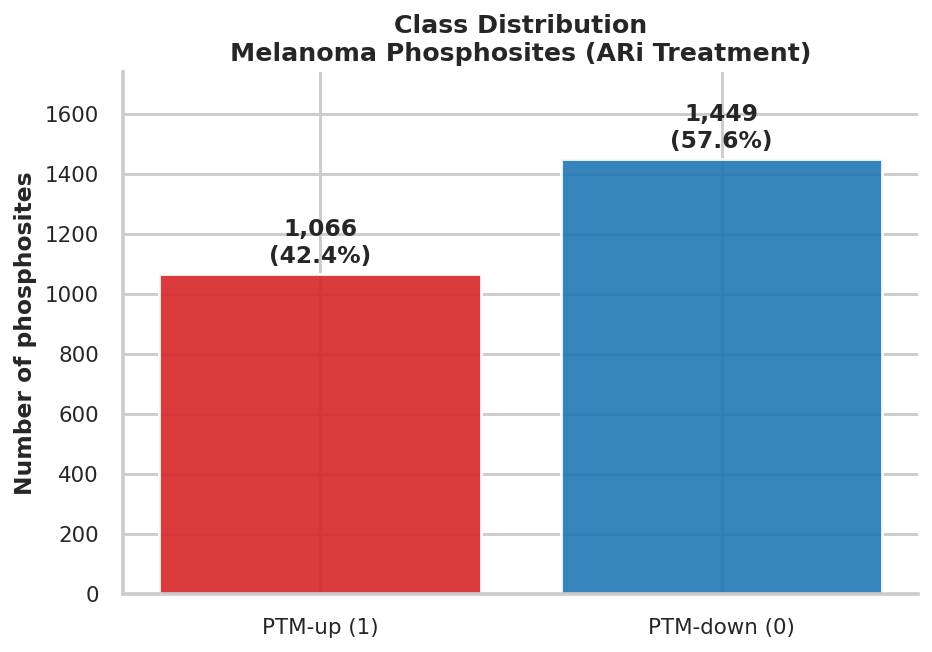

Saved → /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/results_melanoma_phospho_esm2/01_class_distribution.png


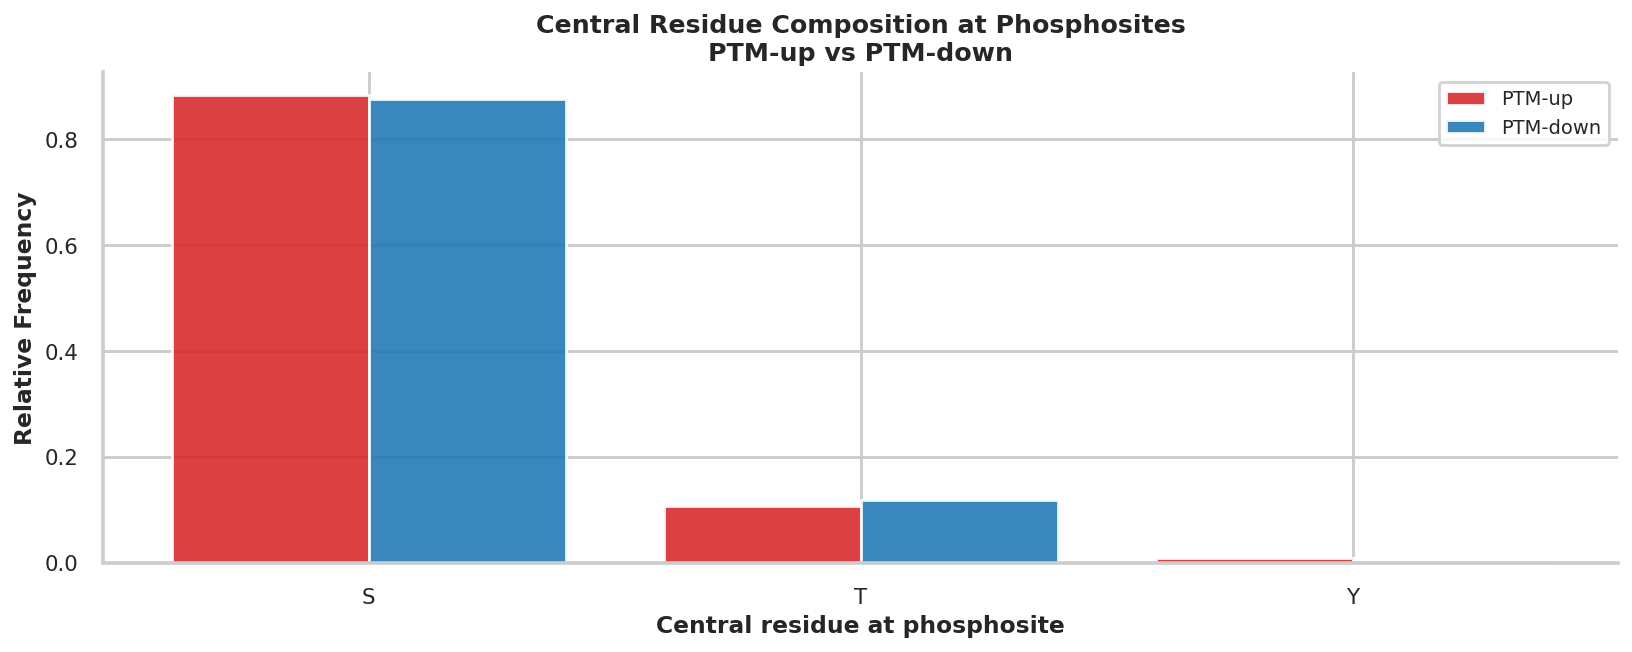

Saved → /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/results_melanoma_phospho_esm2/04_central_residue_composition.png


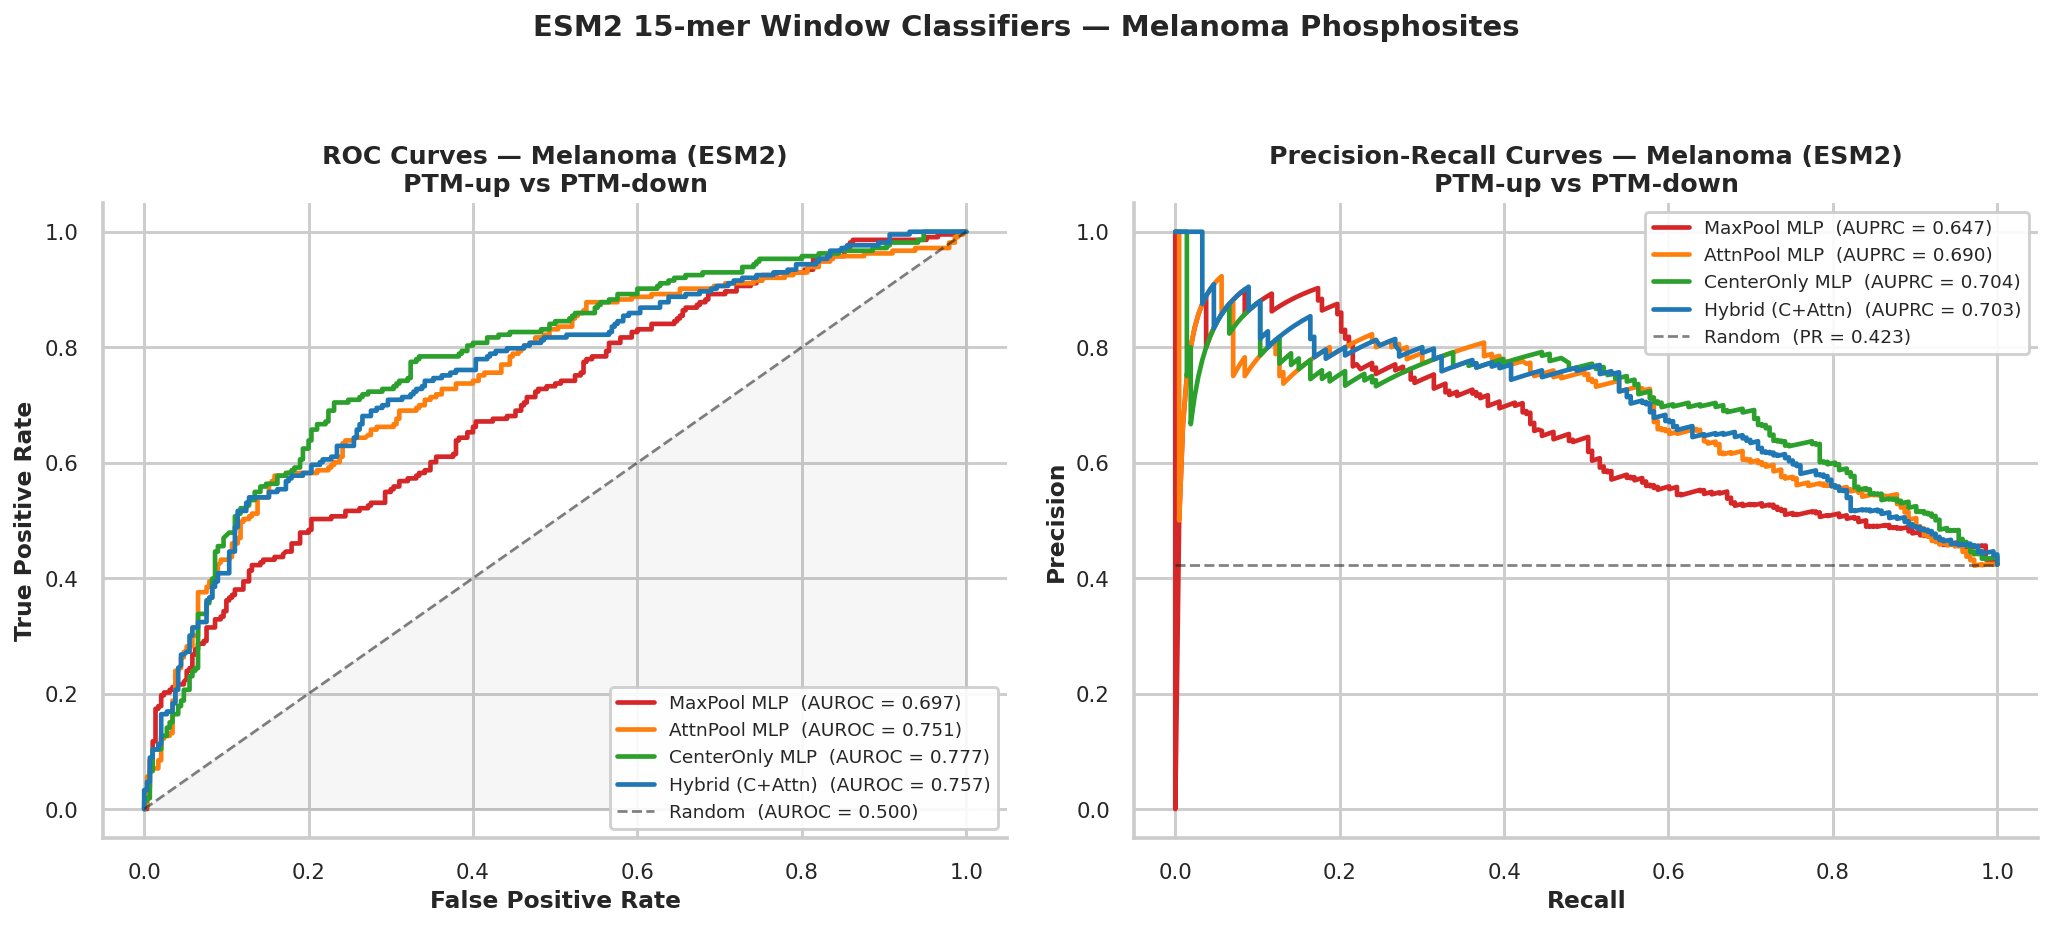

Saved → /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/results_melanoma_phospho_esm2/05_roc_pr_curves.png


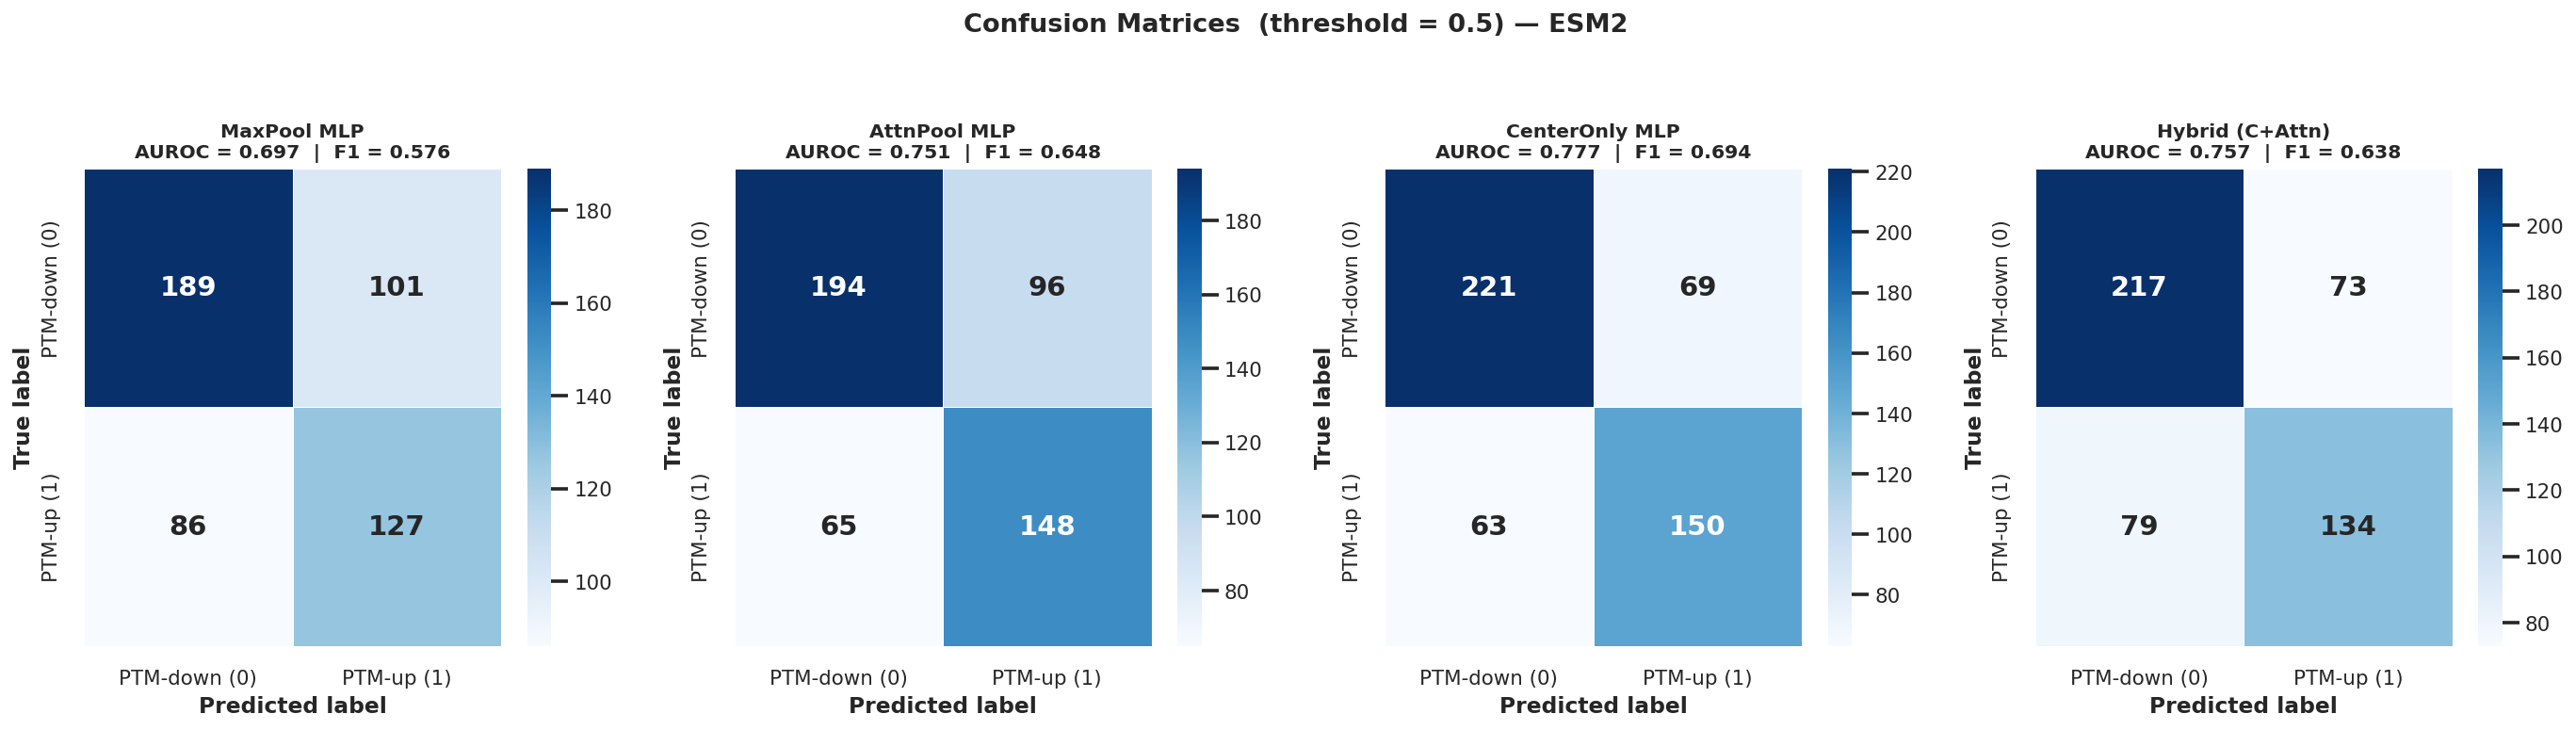

Saved → /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/results_melanoma_phospho_esm2/06_confusion_matrices.png


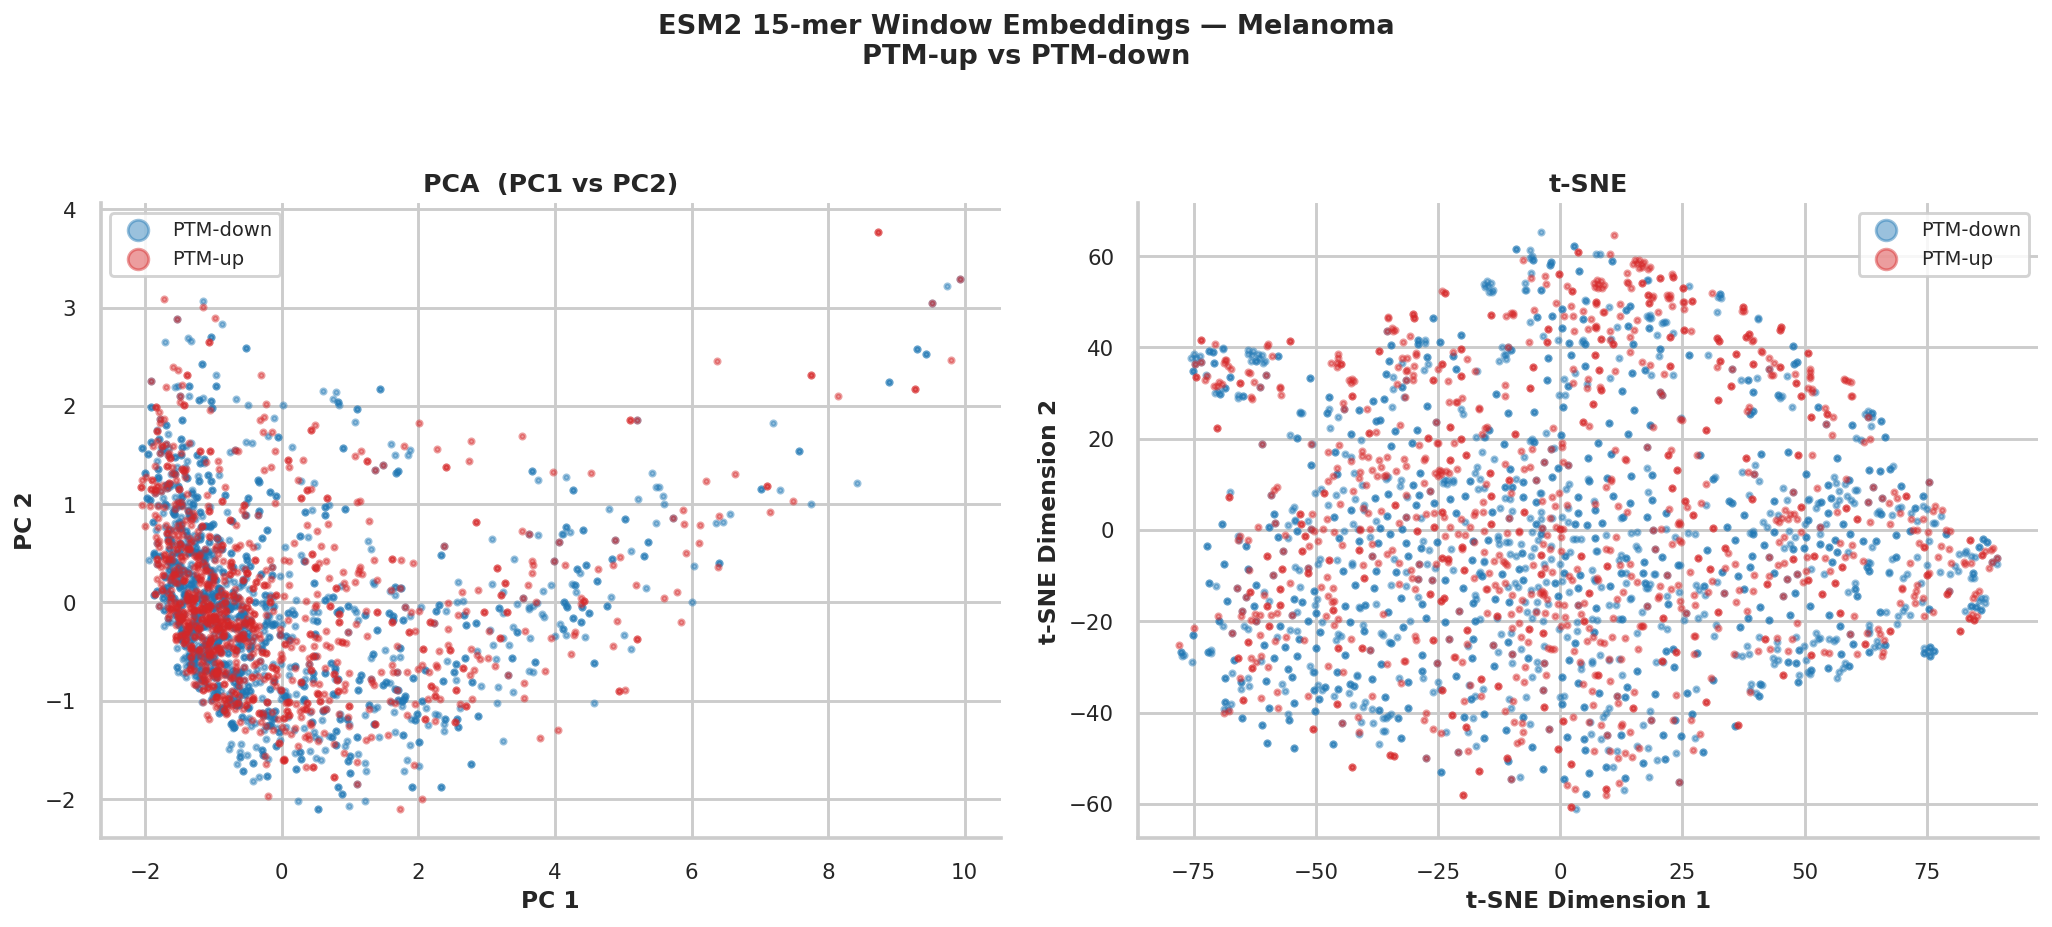

Saved → /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/results_melanoma_phospho_esm2/08_pca_tsne.png


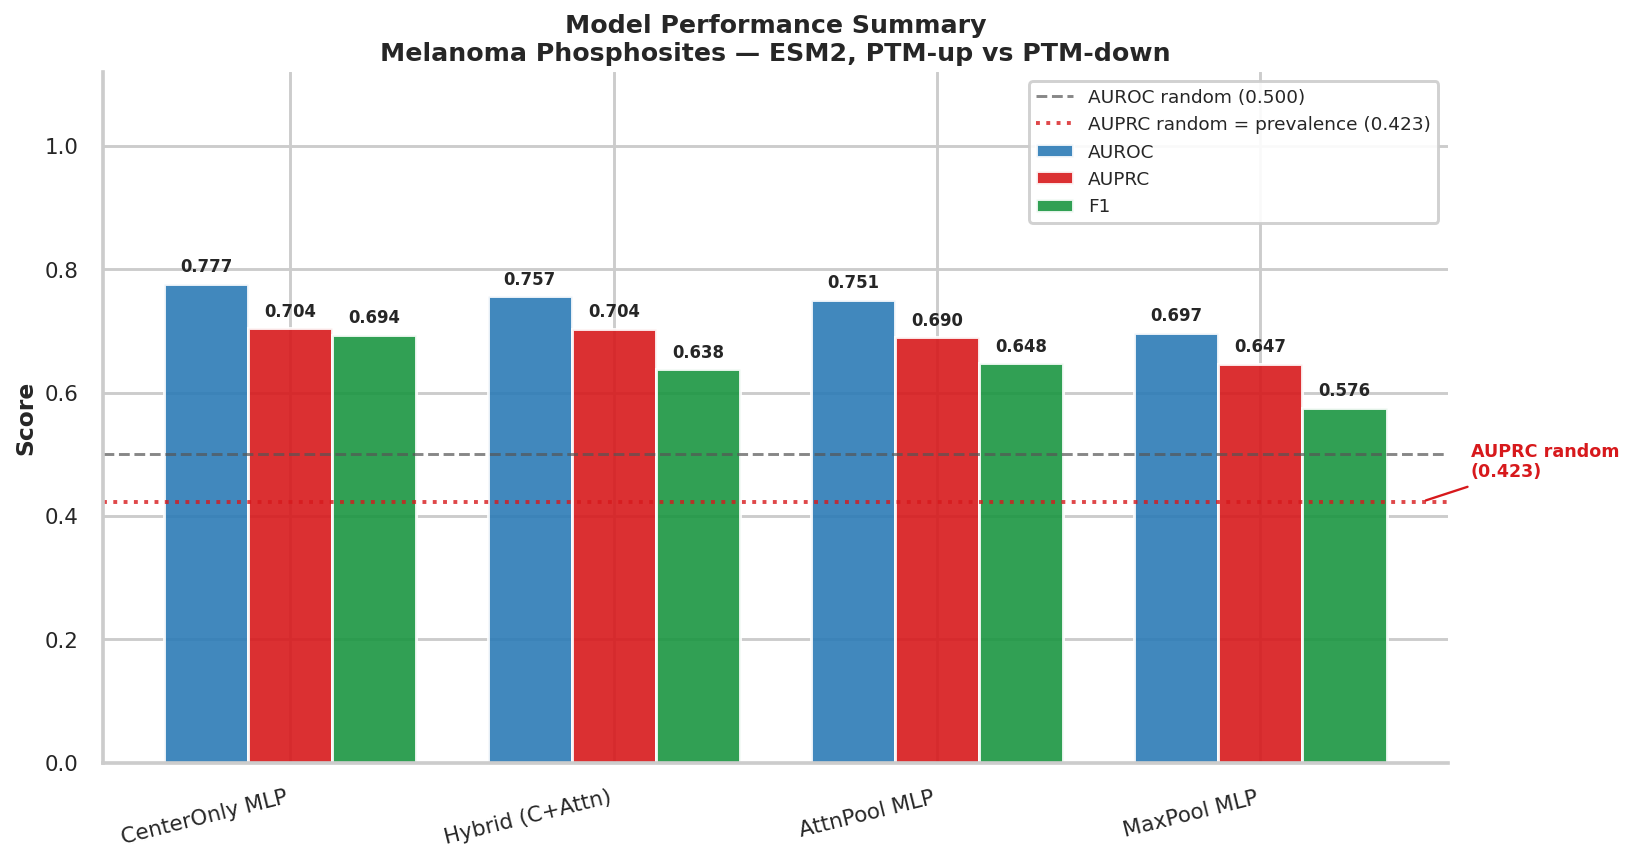

Saved → /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/results_melanoma_phospho_esm2/09_model_performance_summary.png


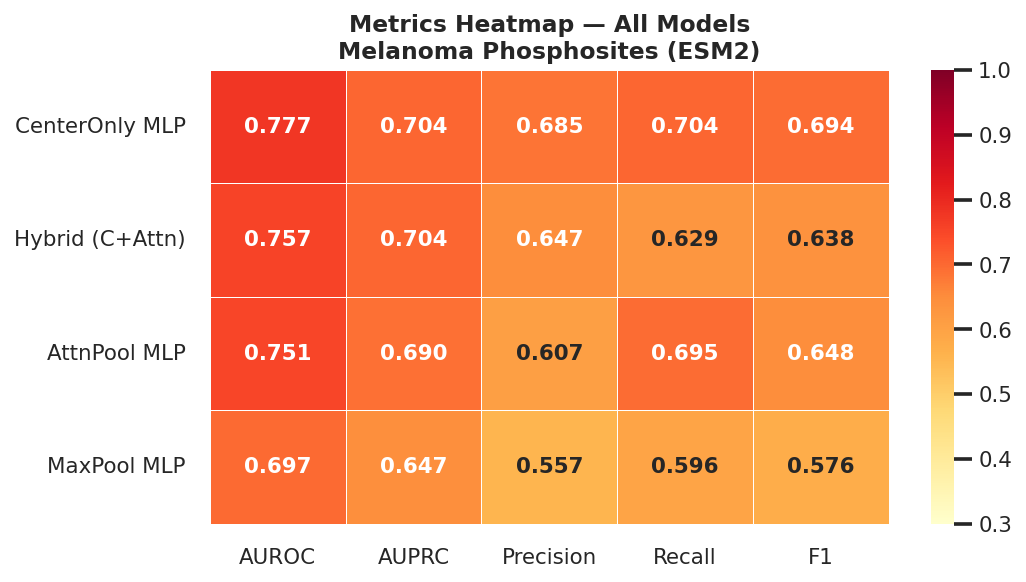

Saved → /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/results_melanoma_phospho_esm2/10_metrics_heatmap.png

  All publication figures saved to:
  /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/results_melanoma_phospho_esm2


In [10]:
# ════════════════════════════════════════════════════════════════════════════
# 6. PUBLICATION-GRADE FIGURES  (numbering mirrors EGFR reference pipeline)
#    01 class_distribution | 04 central_residue | 05 roc_pr | 06 confusion
#    07 model_metrics_summary.csv | 08 pca_tsne | 09 perf_bar | 10 heatmap
# ════════════════════════════════════════════════════════════════════════════
PALETTE4 = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]
RED, BLUE = "#d62728", "#1f77b4"

# ── 01. Class Distribution ────────────────────────────────────────────────────
n_up, n_down = int((y == 1).sum()), int((y == 0).sum())
cc = pd.DataFrame({"Class": ["PTM-up (1)", "PTM-down (0)"], "Count": [n_up, n_down]})
cc["Fraction"] = cc["Count"] / cc["Count"].sum()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(cc["Class"], cc["Count"], color=[RED, BLUE], alpha=0.90, edgecolor="white")
ax.set_ylabel("Number of phosphosites")
ax.set_title("Class Distribution\nMelanoma Phosphosites (ARi Treatment)")
ax.set_ylim(0, cc["Count"].max() * 1.20)
for i, row in cc.iterrows():
    ax.text(i, row["Count"] + cc["Count"].max() * 0.015,
            f'{row["Count"]:,}\n({row["Fraction"]:.1%})',
            ha="center", va="bottom", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "01_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {RESULTS_DIR / '01_class_distribution.png'}")

# ── 04. Central Residue Composition ──────────────────────────────────────────
df_model["center_aa"] = df_model["Site_15mer"].apply(
    lambda s: str(s)[7] if isinstance(s, str) and len(s) >= 8
              and str(s)[7] not in ("_", "-") else None
)
df_up_m   = df_model[df_model["Class"] == 1].dropna(subset=["center_aa"])
df_down_m = df_model[df_model["Class"] == 0].dropna(subset=["center_aa"])
aas       = sorted(set(df_up_m["center_aa"]) | set(df_down_m["center_aa"]))
up_freq   = df_up_m["center_aa"].value_counts(normalize=True).reindex(aas, fill_value=0)
down_freq = df_down_m["center_aa"].value_counts(normalize=True).reindex(aas, fill_value=0)

xp = np.arange(len(aas))
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(xp - 0.2, up_freq.values,   0.4, label="PTM-up",   color=RED,  alpha=0.88, edgecolor="white")
ax.bar(xp + 0.2, down_freq.values, 0.4, label="PTM-down", color=BLUE, alpha=0.88, edgecolor="white")
ax.set_xticks(xp)
ax.set_xticklabels(aas)
ax.set_xlabel("Central residue at phosphosite")
ax.set_ylabel("Relative Frequency")
ax.set_title("Central Residue Composition at Phosphosites\nPTM-up vs PTM-down")
ax.legend(framealpha=0.85)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "04_central_residue_composition.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {RESULTS_DIR / '04_central_residue_composition.png'}")

# ── 05. ROC + PR Curves ───────────────────────────────────────────────────────
baseline_pr = float((y_test == 1).mean())
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for (name, res), color in zip(results.items(), PALETTE4):
    fpr, tpr, _ = roc_curve(y_test, res["probs"])
    axes[0].plot(fpr, tpr, lw=2.4, color=color,
                 label=f"{name}  (AUROC = {res['roc_auc']:.3f})")
    prec_c, rec_c, _ = precision_recall_curve(y_test, res["probs"])
    axes[1].plot(rec_c, prec_c, lw=2.4, color=color,
                 label=f"{name}  (AUPRC = {res['pr_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1.4, alpha=0.55, label="Random  (AUROC = 0.500)")
axes[0].fill_between([0, 1], [0, 1], alpha=0.04, color="k")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — Melanoma (ESM2)\nPTM-up vs PTM-down")
axes[0].legend(loc="lower right", fontsize=9.5, framealpha=0.90)
axes[1].hlines(baseline_pr, 0, 1, linestyles="--", colors="k", lw=1.4, alpha=0.55,
               label=f"Random  (PR = {baseline_pr:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves — Melanoma (ESM2)\nPTM-up vs PTM-down")
axes[1].legend(loc="upper right", fontsize=9.5, framealpha=0.90)
fig.suptitle("ESM2 15-mer Window Classifiers — Melanoma Phosphosites",
             fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "05_roc_pr_curves.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {RESULTS_DIR / '05_roc_pr_curves.png'}")

# ── 06. Confusion Matrices ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 5.5))
if len(results) == 1:
    axes = [axes]
for ax, (name, res), color in zip(axes, results.items(), PALETTE4):
    preds = (res["probs"] >= THRESHOLD).astype(int)
    cm    = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["PTM-down (0)", "PTM-up (1)"],
        yticklabels=["PTM-down (0)", "PTM-up (1)"],
        linewidths=0.5, linecolor="white",
        annot_kws={"size": 15, "weight": "bold"},
    )
    roc = res["roc_auc"]
    f1  = f1_score(y_test, preds, zero_division=0)
    ax.set_title(f"{name}\nAUROC = {roc:.3f}  |  F1 = {f1:.3f}", fontsize=10.5)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
fig.suptitle("Confusion Matrices  (threshold = 0.5) — ESM2",
             fontsize=14, y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "06_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {RESULTS_DIR / '06_confusion_matrices.png'}")

# ── 08. PCA + t-SNE Embedding Visualisation ───────────────────────────────────
label_colors = {1: RED, 0: BLUE}
label_names  = {1: "PTM-up", 0: "PTM-down"}
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for label in [0, 1]:
    mask = y == label
    kw = dict(s=7, alpha=0.45, color=label_colors[label],
              label=label_names[label], rasterized=True)
    axes[0].scatter(X_pca2[mask, 0], X_pca2[mask, 1], **kw)
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], **kw)
for ax, title, xl, yl in zip(
    axes,
    ["PCA  (PC1 vs PC2)", "t-SNE"],
    ["PC 1", "t-SNE Dimension 1"],
    ["PC 2", "t-SNE Dimension 2"],
):
    ax.set_title(title)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.legend(markerscale=4, framealpha=0.85)
fig.suptitle("ESM2 15-mer Window Embeddings — Melanoma\nPTM-up vs PTM-down",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "08_pca_tsne.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {RESULTS_DIR / '08_pca_tsne.png'}")

# ── 09. Model Performance Summary (grouped bar + baselines) ───────────────────
auprc_random = float((y_test == 1).mean())
mp   = metrics_df.set_index("Model")[["AUROC", "AUPRC", "F1"]].copy()
xpos = np.arange(len(mp))
w    = 0.26
fig, ax = plt.subplots(figsize=(12, 6.5))
b1 = ax.bar(xpos - w, mp["AUROC"], w, label="AUROC", color="#2c7bb6", alpha=0.90, edgecolor="white")
b2 = ax.bar(xpos,     mp["AUPRC"], w, label="AUPRC", color="#d7191c", alpha=0.90, edgecolor="white")
b3 = ax.bar(xpos + w, mp["F1"],    w, label="F1",    color="#1a9641", alpha=0.90, edgecolor="white")
ax.axhline(0.500,        ls="--", lw=1.5, color="#555555", alpha=0.70,
           label="AUROC random (0.500)")
ax.axhline(auprc_random, ls=":",  lw=2.0, color="#d7191c", alpha=0.80,
           label=f"AUPRC random = prevalence ({auprc_random:.3f})")
ax.annotate(f"AUPRC random\n({auprc_random:.3f})",
            xy=(len(mp) - 0.5, auprc_random),
            xytext=(len(mp) - 0.35, auprc_random + 0.04),
            fontsize=9, color="#d7191c", fontweight="bold",
            arrowprops=dict(arrowstyle="-", color="#d7191c", lw=1.2))
ax.set_xticks(xpos)
ax.set_xticklabels(mp.index, rotation=14, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.12)
ax.set_title("Model Performance Summary\nMelanoma Phosphosites — ESM2, PTM-up vs PTM-down")
ax.legend(loc="upper right", framealpha=0.90, fontsize=9.5)
for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.013,
                f"{bar.get_height():.3f}", ha="center", va="bottom",
                fontsize=8.5, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "09_model_performance_summary.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {RESULTS_DIR / '09_model_performance_summary.png'}")

# ── 10. Metrics Heatmap ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))
hm_data = metrics_df.set_index("Model")[["AUROC", "AUPRC", "Precision", "Recall", "F1"]]
sns.heatmap(
    hm_data, annot=True, fmt=".3f", cmap="YlOrRd",
    vmin=0.3, vmax=1.0, linewidths=0.5, linecolor="white",
    annot_kws={"size": 11, "weight": "bold"}, ax=ax,
)
ax.set_title("Metrics Heatmap — All Models\nMelanoma Phosphosites (ESM2)", fontsize=12)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "10_metrics_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {RESULTS_DIR / '10_metrics_heatmap.png'}")

print(f"\n{'='*60}")
print(f"  All publication figures saved to:")
print(f"  {RESULTS_DIR}")
print(f"{'='*60}")


In [11]:
# ── HTML Summary Report (mirrors EGFR reference pipeline) ────────────────────
import base64


def img_to_b64(path: Path) -> str:
    with open(path, "rb") as f:
        data = base64.b64encode(f.read()).decode("utf-8")
    return f'<img src="data:image/png;base64,{data}" style="max-width:100%;"/>'


plot_files   = sorted(RESULTS_DIR.glob("*.png"))
metrics_html = metrics_df.to_html(index=False, border=1,
                                   classes="metrics", justify="center")

html_parts = [
    f"""<!DOCTYPE html>
<html><head>
<meta charset='utf-8'/>
<title>ESM2 Phospho Melanoma — Analysis Report</title>
<style>
  body {{ font-family: Arial, sans-serif; max-width: 1100px; margin: auto; padding: 20px; }}
  h1   {{ color: #1a3c34; }}
  h2   {{ color: #2c3e50; border-bottom: 2px solid #ccc; padding-bottom: 4px; }}
  table.metrics {{ border-collapse: collapse; width: 100%; }}
  table.metrics th, table.metrics td {{ border: 1px solid #aaa; padding: 8px 14px; text-align: center; }}
  table.metrics th {{ background-color: #1a3c34; color: white; }}
  .plot-grid {{ display: flex; flex-wrap: wrap; gap: 16px; }}
  .plot-grid figure {{ margin: 0; text-align: center; }}
</style>
</head><body>
<h1>ESM2 Melanoma Phosphorylation Classifier</h1>
<h2>Dataset: Melanoma Cells — ARi Treatment (PTM-up vs PTM-down)</h2>
<p><b>PTM-up (1):</b> {n_up} sites &nbsp;|&nbsp; <b>PTM-down (0):</b> {n_down} sites</p>
<p><b>Model:</b> ESM2 esm2_t33_650M_UR50D ({EMBED_DIM}-dim) · 15-residue context window around phosphosite</p>
<hr/>
<h2>Model Performance Summary</h2>
""",
    metrics_html,
    "<hr/>\n<h2>Plots</h2>\n<div class='plot-grid'>\n",
]

for p in plot_files:
    html_parts.append(f"<figure>{img_to_b64(p)}<figcaption>{p.name}</figcaption></figure>\n")

html_parts.append("</div></body></html>")

report_path = RESULTS_DIR / "report_phospho_esm2.html"
report_path.write_text("".join(html_parts), encoding="utf-8")
print(f"HTML report saved → {report_path}")


HTML report saved → /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/results_melanoma_phospho_esm2/report_phospho_esm2.html


In [12]:
# ── Final Summary vs Random Baseline ─────────────────────────────────────────
random_auroc = 0.500
random_prauc = float((y_test == 1).mean())

print("=" * 60)
print("FINAL RESULTS — ESM2 | Melanoma PTM-up vs PTM-down")
print("=" * 60)
print(f"Embedder : ESM2 esm2_t33_650M_UR50D  ({EMBED_DIM}-dim)")
print(f"Samples  : {len(X)} total  |  PTM-up: {(y==1).sum()}  PTM-down: {(y==0).sum()}")
print(f"Split    : 80% train / 20% test, stratified")
print()
print(f"Random baselines (test):  AUROC = {random_auroc:.4f}  |  AUPRC = {random_prauc:.4f}")
print()
print(f"{'Model':<22} {'AUROC':>7} {'ΔAUROC':>8} {'AUPRC':>7} {'ΔAUPRC':>8} {'F1':>7}")
print("-" * 65)
for _, row in metrics_df.iterrows():
    print(f"{row['Model']:<22} {row['AUROC']:>7.4f} "
          f"{row['AUROC']-random_auroc:>+8.4f} "
          f"{row['AUPRC']:>7.4f} "
          f"{row['AUPRC']-random_prauc:>+8.4f} "
          f"{row['F1']:>7.4f}")
print()
best = metrics_df.iloc[0]
print(f"Best model : {best['Model']}")
print(f"  AUROC  = {best['AUROC']:.4f}  (Δ vs random = {best['AUROC']-random_auroc:+.4f})")
print(f"  AUPRC  = {best['AUPRC']:.4f}  (Δ vs random = {best['AUPRC']-random_prauc:+.4f})")
print(f"  F1     = {best['F1']:.4f}")
print()
print(f"Outputs saved to: {RESULTS_DIR.resolve()}")
for f in sorted(RESULTS_DIR.iterdir()):
    print(f"  {f.name}")

FINAL RESULTS — ESM2 | Melanoma PTM-up vs PTM-down
Embedder : ESM2 esm2_t33_650M_UR50D  (1280-dim)
Samples  : 2515 total  |  PTM-up: 1066  PTM-down: 1449
Split    : 80% train / 20% test, stratified

Random baselines (test):  AUROC = 0.5000  |  AUPRC = 0.4235

Model                    AUROC   ΔAUROC   AUPRC   ΔAUPRC      F1
-----------------------------------------------------------------
CenterOnly MLP          0.7770  +0.2770  0.7042  +0.2807  0.6944
Hybrid (C+Attn)         0.7566  +0.2566  0.7035  +0.2800  0.6381
AttnPool MLP            0.7512  +0.2512  0.6898  +0.2663  0.6477
MaxPool MLP             0.6972  +0.1972  0.6468  +0.2233  0.5760

Best model : CenterOnly MLP
  AUROC  = 0.7770  (Δ vs random = +0.2770)
  AUPRC  = 0.7042  (Δ vs random = +0.2807)
  F1     = 0.6944

Outputs saved to: /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/results_melanoma_phospho_esm2
  01_class_distribution.png
  04_central_residue_comp